In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlite3 as sql
import hashlib
import hmac
import uuid
from datetime import datetime
from cryptography.fernet import Fernet
import base64
import dask
import kagglehub
import psycopg2

In [3]:

server_con = psycopg2.connect(
	host="localhost",
	port="5433",
	database="Global EV & Battery Supply Chain Dataset 2026",
	user="postgres",
	password="090686@mn",
)

In [4]:
raw_data = pd.read_sql_query("SELECT * FROM chargers_raw", server_con)

C:\Users\antmi\AppData\Local\Temp\ipykernel_33480\3705509664.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_data = pd.read_sql_query("SELECT * FROM chargers_raw", server_con)


In [5]:
raw_data.head()

,station_id,uuid,station_type,latitude,longitude,address,city,state_province,country_iso2,country_iso3,n_connectors,max_power_kw,date_created,date_last_verified
0,480562.0,F3777FF6-0D52-4878-98A5-036D375AEC11,DC Fast,38.897385,-121.322120,2290 Nicolaus Rd #106,Lincoln,CA,US,USA,1,400.0,2026-03-25 04:01:00,2026-03-25 04:01:00
1,480561.0,627E6848-49F1-4391-8AB8-949F3E41B39F,DC Fast,38.740730,-121.169716,8701 Auburn Folsom Rd,Granite Bay,CA,US,USA,2,400.0,2026-03-25 03:58:00,2026-03-25 03:58:00
2,480560.0,2E707B96-7B76-432B-9053-1914C3F906F2,DC Fast,38.676160,-121.198670,9475 Madison Ave,Folsom,CA,US,USA,2,400.0,2026-03-25 03:48:00,2026-03-25 03:50:00
3,480559.0,340918CD-2F74-4E60-9E75-303BD029D675,DC Fast,38.547510,-121.396310,8371 Folsom Blvd,Sacramento,CA,US,USA,2,400.0,2026-03-25 03:44:00,2026-03-25 03:54:00
4,480552.0,EF567546-893A-4876-AA82-2389A9B90E6E,Unknown,35.135586,-116.213130,65857 Rasor Rd,Baker,California,US,USA,0,NaN,2026-03-21 16:08:00,2026-03-25 04:01:00


In [6]:
raw_data.dtypes

station_id                   float64
uuid                          object
station_type                  object
latitude                     float64
longitude                    float64
address                       object
city                          object
state_province                object
country_iso2                  object
country_iso3                  object
n_connectors                   int64
max_power_kw                 float64
date_created          datetime64[ns]
date_last_verified    datetime64[ns]
dtype: object

In [7]:
raw_data.latitude.unique()

array([38.897385, 38.74073 , 38.67616 , ..., 49.18954 , 49.188118,
       49.155205], shape=(67293,))

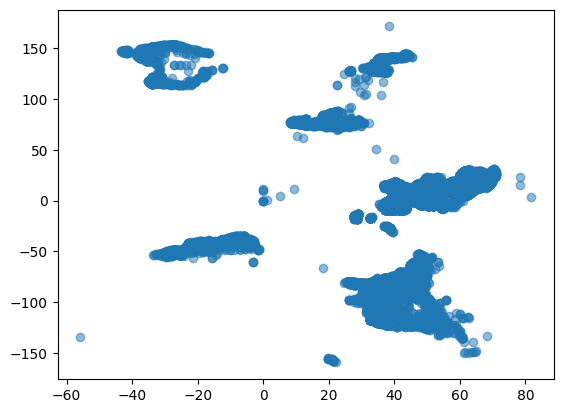

In [8]:
plot_data = raw_data[['latitude', 'longitude']].dropna()
plt.scatter(plot_data.latitude, plot_data.longitude, alpha=0.5)

In [9]:
charger_data = raw_data[['station_id', 'uuid', 'station_type', 'max_power_kw']].rename(
	columns={'station_type': 'charger_type'}
)

In [10]:
charger_data

,station_id,uuid,charger_type,max_power_kw
0,480562.0,F3777FF6-0D52-4878-98A5-036D375AEC11,DC Fast,400.0
1,480561.0,627E6848-49F1-4391-8AB8-949F3E41B39F,DC Fast,400.0
2,480560.0,2E707B96-7B76-432B-9053-1914C3F906F2,DC Fast,400.0
3,480559.0,340918CD-2F74-4E60-9E75-303BD029D675,DC Fast,400.0
4,480552.0,EF567546-893A-4876-AA82-2389A9B90E6E,Unknown,NaN
...,...,...,...,...
67895,47332.0,BC82FD84-CA18-42C7-A96D-AAC23BF7EA62,DC Fast,22.0
67896,43488.0,CB36E45E-567E-47C1-967B-506631D629D5,DC Fast,50.0
67897,41838.0,17960C35-010C-48E9-88A5-0E53374AB05C,DC Fast,60.0
67898,24713.0,D6A71178-97B0-4F21-B48C-ADA1BEACB24A,AC Level 2,22.0


In [12]:
raw_data.country_iso2.value_counts()


country_iso2
NL    4998
CA    4998
US    4997
FR    4996
ES    4993
GB    4989
IT    4976
SE    4963
DE    4949
NO    4794
PT    3719
DK    2202
FI    1893
IN    1712
JP    1641
AT    1326
AU    1291
BE    1265
BR     998
CH     906
CZ     633
PL     485
KR     161
CN      15
Name: count, dtype: int64